In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import early_stopping # Import early stopping callback

# Loaded the dataset
try:
    df = pd.read_csv('/content/csv data.csv')
    print("Dataset loaded successfully.")
    print("Columns in the dataset:", df.columns.tolist())
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
    print("\nDataset Info:")
    df.info()
except FileNotFoundError:
    print("Error: 'csv data.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# Assumed column names based on the problem description
MONTH_COL = 'Month' # Corrected from 'Date' to 'Month' based on data preview
SKU_COL = 'SKU'
CATEGORY_COL = 'Category' # Added Category column name
REGION_COL = 'Region'
ACTUAL_SALES_COL = 'Actual_Sales'
STAT_FORECAST_COL = 'Statistical_Forecast' # Corrected column name
CONSENSUS_FORECAST_COL = 'Consensus_Forecast'
PROMOTION_FLAG_COL = 'Promotion_Flag'
STOCKOUT_FLAG_COL = 'Stockout_Flag'

#  Data Preprocessing and Feature Engineering

# Converted Month column to datetime and create time-based features
if MONTH_COL in df.columns:
    df[MONTH_COL] = pd.to_datetime(df[MONTH_COL])
    df['Year'] = df[MONTH_COL].dt.year
    df['Month_Num'] = df[MONTH_COL].dt.month # Renamed to avoid conflict with original 'Month' column if kept
    df['DayOfWeek'] = df[MONTH_COL].dt.dayofweek # Although monthly, this might capture weekly patterns if data is aggregated monthly
    df['DayOfYear'] = df[MONTH_COL].dt.dayofyear
    df['WeekOfYear'] = df[MONTH_COL].dt.isocalendar().week.astype(int)
    # Sort by SKU, Region, and Month to ensure correct lag calculation
    df = df.sort_values(by=[SKU_COL, REGION_COL, MONTH_COL]).reset_index(drop=True)

    # Createed lag features for Actual_Sales and Statistical_ForecastData
    # Lags are crucial for time series forecasting.
    # We created lags grouped by SKU and Region to avoid data leakage across different products/locations.
    for lag in range(1, 4): # Create lags for 1, 2, and 3 months
        df[f'Actual_Sales_Lag_{lag}'] = df.groupby([SKU_COL, REGION_COL])[ACTUAL_SALES_COL].shift(lag)
        df[f'Stat_Forecast_Lag_{lag}'] = df.groupby([SKU_COL, REGION_COL])[STAT_FORECAST_COL].shift(lag)

    # Created rolling mean features
    for window in [2, 3]: # Rolling mean for 2 and 3 months
        df[f'Actual_Sales_RollingMean_{window}'] = df.groupby([SKU_COL, REGION_COL])[ACTUAL_SALES_COL].transform(lambda x: x.rolling(window=window, min_periods=1).mean().shift(1))

else:
    print(f"Warning: '{MONTH_COL}' column not found. Proceeding without time-based features and lag/rolling features.")
    print("Please ensure your CSV contains a date column for optimal time-series modeling.")

# Labeled Encode categorical features (SKU, Category, Region, Promotion_Flag, Stockout_Flag)
categorical_cols = [SKU_COL, CATEGORY_COL, REGION_COL, PROMOTION_FLAG_COL, STOCKOUT_FLAG_COL]

# Custom handling for SKU_COL to ensure natural sorting after encoding
if SKU_COL in df.columns:
    # Get unique SKUs and sort them naturally before encoding
    unique_skus = df[SKU_COL].astype(str).unique()
    unique_skus.sort() # Sorts lexicographically, which typically works for SKU-XX formats
    sku_le = LabelEncoder()
    sku_le.fit(unique_skus) # Fit on the naturally sorted unique SKUs
    df[SKU_COL] = sku_le.transform(df[SKU_COL].astype(str)) # Transform the column

# Handled other categorical columns normally
for col in [c for c in categorical_cols if c != SKU_COL]: # Exclude SKU_COL as it's already handled
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str)) # Convert to string to handle potential mixed types

# Imputed NaNs introduced by lag/rolling features BEFORE defining X and y
# Filled NaNs with 0 so that the model can predict for all rows.
lag_rolling_cols = [col for col in df.columns if 'Lag' in col or 'RollingMean' in col]
df[lag_rolling_cols] = df[lag_rolling_cols].fillna(0) # Fill NaNs for the entire dataframe

# Now, df_model will be the entire df, as NaNs from feature engineering are handled
df_model = df.copy()

print("\nShape of dataframe after preprocessing and NaN imputation:", df_model.shape)
print("First 5 rows of dataframe used for modeling (with NaNs filled):")
print(df_model.head())

# Defined features (X) and target (y)
# Excluded the original 'Month' column if new date features were created from it
features = [col for col in df_model.columns if col not in [MONTH_COL, ACTUAL_SALES_COL, CONSENSUS_FORECAST_COL]]
X = df_model[features]
y = df_model[ACTUAL_SALES_COL]

# Split data into training and validation sets for initial evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialized and trained the LightGBM Regressor model with early stopping
lgbm = LGBMRegressor(random_state=42, n_estimators=500, learning_rate=0.05, num_leaves=31)
print("\nTraining LightGBM model with early stopping...")
# Used early stopping: monitor 'l1' (MAE) on the test set
lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='l1', callbacks=[early_stopping(stopping_rounds=50, verbose=-1)])
print("Model training complete.")

# Evaluated the model on the test set
y_pred_lgbm = lgbm.predict(X_test)

# Calculated accuracy metrics for LGBM
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

# Evaluated the original Statistical Forecast on the test set for comparison
# Ensured 'STAT_FORECAST_COL' is present in X_test as it's a feature.
original_stat_forecast_test = X_test[STAT_FORECAST_COL]

mae_stat_original = mean_absolute_error(y_test, original_stat_forecast_test)
rmse_stat_original = np.sqrt(mean_squared_error(y_test, original_stat_forecast_test))

print("\n--- Forecast Accuracy Comparison (on Test Set) ---")
print(f"Original Statistical Forecast - MAE: {mae_stat_original:.2f}, RMSE: {rmse_stat_original:.2f}")
print(f"Improved Statistical Forecast (LGBM) - MAE: {mae_lgbm:.2f}, RMSE: {rmse_lgbm:.2f}")

# Determine if the improved forecast is better
if mae_lgbm < mae_stat_original:
    print(f"\nConclusion: The Improved Statistical Forecast (LGBM) is BETTER, with a {((mae_stat_original - mae_lgbm) / mae_stat_original) * 100:.2f}% reduction in MAE.")
else:
    print(f"\nConclusion: The Improved Statistical Forecast (LGBM) is NOT better than the original Statistical Forecast on this test set. Difference: {mae_lgbm - mae_stat_original:.2f}")

# Generated the 'Improved_Stat_Forecast' for the entire dataset
# Retrained on the full 'df_model' (which is now the full original df with imputed features)
print("\nGenerating 'Improved_Stat_Forecast' for the entire dataset...")
final_lgbm = LGBMRegressor(random_state=42, n_estimators=500, learning_rate=0.05, num_leaves=31)
# For the final model, train on all available data without early stopping to utilize all data points.
final_lgbm.fit(X, y)

# Added the 'Improved_Stat_Forecast' directly to the 'df_model' (which contains all original rows with imputed features)
df_model['Improved_Stat_Forecast'] = np.ceil(final_lgbm.predict(X)) # Rounded up

# The df_final is now essentially df_model with the new forecast column
df_final = df_model.copy()

# Display a sample of the results
print("\nSample of Actual Sales, Original Statistical Forecast, and Improved Statistical Forecast:")
print(df_final[[MONTH_COL, SKU_COL, REGION_COL, ACTUAL_SALES_COL, STAT_FORECAST_COL, 'Improved_Stat_Forecast']].head(10))

# The improved_forecast_data will now contain predictions for all 960 rows
improved_forecast_data = df_final[['Improved_Stat_Forecast']]
print(f"\nGenerated {len(improved_forecast_data)} rows for 'Improved_Stat_Forecast'.")
print("These values can now be used to update your Excel file.")

# Final check for output
print("\nSummary of Improved_Stat_Forecast values:")
print(improved_forecast_data.describe())

Dataset loaded successfully.
Columns in the dataset: ['SKU', 'Category', 'Region', 'Month', 'Actual_Sales', 'Statistical_Forecast', 'Consensus_Forecast', 'Promotion_Flag', 'Stockout_Flag']

First 5 rows of the dataset:
         SKU           Category Region    Month  Actual_Sales  \
0  SKU-OS-01  Orthopedic Screws   APAC  2024-01           147   
1  SKU-OS-01  Orthopedic Screws   APAC  2024-02           161   
2  SKU-OS-01  Orthopedic Screws   APAC  2024-03           104   
3  SKU-OS-01  Orthopedic Screws   APAC  2024-04            94   
4  SKU-OS-01  Orthopedic Screws   APAC  2024-05           166   

   Statistical_Forecast  Consensus_Forecast  Promotion_Flag  Stockout_Flag  
0                   198                 146               0              0  
1                   175                 162               0              0  
2                   134                  91               0              1  
3                   104                  93               0              1  
4    

### Improve Model Performance: Hyperparameter Tuning

To further enhance the LightGBM model's accuracy, we can perform hyperparameter tuning. This involves searching for the optimal combination of parameters that yield the best performance on your data.

We will use `GridSearchCV` from `sklearn.model_selection` to systematically explore a predefined grid of hyperparameter values.

In [7]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
# These ranges are examples; you might want to adjust them based on initial results or domain knowledge.
param_grid = {
    'n_estimators': [300, 500, 700], # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage to prevent overfitting
    'num_leaves': [20, 31, 40], # Maximum tree leaves for base learners
    'max_depth': [-1, 10, 15], # Maximum tree depth for base learners (-1 means no limit)
    'min_child_samples': [20, 30], # Minimum number of data needed in a child (leaf)
}

# Initialize LightGBM Regressor
lgbm_grid = LGBMRegressor(random_state=42)

# Initialize GridSearchCV
# We'll use MAE (neg_mean_absolute_error) as the scoring metric, as you are focused on MAE reduction.
# cv=3 for 3-fold cross-validation
grid_search = GridSearchCV(estimator=lgbm_grid, param_grid=param_grid,
                           scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=2)

print("Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV on the entire dataset (X, y) for the final model
grid_search.fit(X, y)

print("GridSearchCV complete.")

# Print the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best MAE found (negative because GridSearchCV minimizes): {-grid_search.best_score_:.2f}")

# Get the best estimator
best_lgbm_model = grid_search.best_estimator_

# Generate the 'Improved_Stat_Forecast' with the best model
df_final_tuned = df_model.copy() # Use a copy of df_model to avoid altering the original 'df_model'
df_final_tuned['Improved_Stat_Forecast_Tuned'] = np.ceil(best_lgbm_model.predict(X))

print("\nSample of Actual Sales, Original Statistical Forecast, and Tuned Improved Statistical Forecast:")
print(df_final_tuned[[MONTH_COL, SKU_COL, REGION_COL, ACTUAL_SALES_COL, STAT_FORECAST_COL, 'Improved_Stat_Forecast_Tuned']].head(10))

print(f"\nGenerated {len(df_final_tuned['Improved_Stat_Forecast_Tuned'])} rows for 'Improved_Stat_Forecast_Tuned'.")

print("\nSummary of Improved_Stat_Forecast_Tuned values:")
print(df_final_tuned['Improved_Stat_Forecast_Tuned'].describe())

# You can then export this new df_final_tuned to a CSV if satisfied with the results.
# df_final_tuned.to_csv('demand_planning_results_tuned.csv', index=False)
# print("Tuned dataset exported to 'demand_planning_results_tuned.csv'.")

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 162 candidates, totalling 486 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1764
[LightGBM] [Info] Number of data points in the train set: 960, number of used features: 19
[LightGBM] [Info] Start training from score 116.694792
GridSearchCV complete.

Best parameters found: {'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 30, 'n_estimators': 500, 'num_leaves': 20}
Best MAE found (negative because GridSearchCV minimizes): 9.69

Sample of Actual Sales, Original Statistical Forecast, and Tuned Improved Statistical Forecast:
       Month  SKU  Region  Actual_Sales  Statistical_Forecast  \
0 2024-01-01    0       0            77                    93   
1 2024-02-01    0       0            7

In [8]:
df_final_tuned.to_csv('demand_planning_results_tuned.csv', index=False)
print("Tuned dataset with 'Improved_Stat_Forecast_Tuned' exported to 'demand_planning_results_tuned.csv'.")

Tuned dataset with 'Improved_Stat_Forecast_Tuned' exported to 'demand_planning_results_tuned.csv'.


In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# To correctly inverse transform Category and Region, we need access to their original string values.
# The 'df' DataFrame has already had these columns encoded. So, we'll temporarily load the raw data again.
raw_df = pd.read_csv('/content/csv data.csv')

# Create LabelEncoders for Category and Region and fit them on the original (non-encoded) columns from raw_df
le_category = LabelEncoder()
le_region = LabelEncoder()

# Fit them on the original string columns from the raw data
le_category.fit(raw_df[CATEGORY_COL].astype(str))
le_region.fit(raw_df[REGION_COL].astype(str))

# Make a copy of df_final_tuned to work with for output
df_output = df_final_tuned.copy()

# Inverse transform encoded columns back to original string values
# sku_le is correctly fitted on the original SKUs from the main preprocessing cell
df_output['Original_SKU'] = sku_le.inverse_transform(df_output[SKU_COL].astype(int))

# Now, apply the inverse transform using the correctly fitted LabelEncoders for Category and Region
df_output[CATEGORY_COL] = le_category.inverse_transform(df_output[CATEGORY_COL].astype(int))
df_output[REGION_COL] = le_region.inverse_transform(df_output[REGION_COL].astype(int))

# Sort by Category A-Z as requested by the user
df_output_sorted = df_output.sort_values(by=CATEGORY_COL).reset_index(drop=True)

# Define the desired columns and their order for the output CSV
# Including all original columns and the new forecast
output_columns = [
    'Original_SKU',
    CATEGORY_COL,
    REGION_COL,
    MONTH_COL,
    ACTUAL_SALES_COL,
    STAT_FORECAST_COL,
    CONSENSUS_FORECAST_COL,
    PROMOTION_FLAG_COL,
    STOCKOUT_FLAG_COL,
    'Improved_Stat_Forecast_Tuned'
]

# Select and reorder columns
df_final_csv = df_output_sorted[output_columns]

# Display the head to confirm the structure and sorting
print("Final DataFrame structure for CSV export (sorted by Category, with original values):")
display(df_final_csv.head())

# Export to CSV
output_filename = 'demand_planning_results_final_user_format.csv'
df_final_csv.to_csv(output_filename, index=False)
print(f"\nFinal dataset exported to '{output_filename}'.")

Final DataFrame structure for CSV export (sorted by Category, with original values):


,Original_SKU,Category,Region,Month,Actual_Sales,Statistical_Forecast,Consensus_Forecast,Promotion_Flag,Stockout_Flag,Improved_Stat_Forecast_Tuned
0,SKU-IP-01,Infusion Pumps,APAC,2024-01-01,77,93,76,0,0,88.0
1,SKU-IP-02,Infusion Pumps,EMEA,2024-03-01,202,207,196,0,0,205.0
2,SKU-IP-02,Infusion Pumps,EMEA,2024-04-01,201,226,218,0,0,197.0
3,SKU-IP-02,Infusion Pumps,EMEA,2024-05-01,188,172,195,0,0,175.0
4,SKU-IP-02,Infusion Pumps,EMEA,2024-06-01,168,181,157,0,0,168.0



Final dataset exported to 'demand_planning_results_final_user_format.csv'.


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import early_stopping

# --- Configuration and Column Definitions ---
# Adjust these names if they are different in your CSV
CSV_FILE_PATH = '/content/csv data.csv'
MONTH_COL = 'Month'
SKU_COL = 'SKU'
CATEGORY_COL = 'Category'
REGION_COL = 'Region'
ACTUAL_SALES_COL = 'Actual_Sales'
STAT_FORECAST_COL = 'Statistical_Forecast'
CONSENSUS_FORECAST_COL = 'Consensus_Forecast'
PROMOTION_FLAG_COL = 'Promotion_Flag' # Corrected from 'Promotion_FLAG'
STOCKOUT_FLAG_COL = 'Stockout_Flag'   # Corrected from 'Stockout_FLAG'
OUTPUT_CSV_FILENAME = 'demand_planning_results_final_user_format.csv'

# --- 1. Data Loading ---
try:
    df = pd.read_csv(CSV_FILE_PATH)
    print(f"Dataset '{CSV_FILE_PATH}' loaded successfully.")
except FileNotFoundError:
    print(f"Error: '{CSV_FILE_PATH}' not found. Please ensure the file is in the correct directory.")
    exit()

# Keep a copy of the raw data for inverse transformation later if needed
raw_df_copy = df.copy()

# --- 2. Data Preprocessing and Feature Engineering ---

# Convert Month column to datetime and create time-based features
if MONTH_COL in df.columns:
    df[MONTH_COL] = pd.to_datetime(df[MONTH_COL])
    df['Year'] = df[MONTH_COL].dt.year
    df['Month_Num'] = df[MONTH_COL].dt.month
    df['DayOfWeek'] = df[MONTH_COL].dt.dayofweek
    df['DayOfYear'] = df[MONTH_COL].dt.dayofyear
    df['WeekOfYear'] = df[MONTH_COL].dt.isocalendar().week.astype(int)

    # Sort by SKU, Region, and Month to ensure correct lag calculation
    df = df.sort_values(by=[SKU_COL, REGION_COL, MONTH_COL]).reset_index(drop=True)

    # Create lag features
    for lag in range(1, 4):
        df[f'Actual_Sales_Lag_{lag}'] = df.groupby([SKU_COL, REGION_COL])[ACTUAL_SALES_COL].shift(lag)
        df[f'Stat_Forecast_Lag_{lag}'] = df.groupby([SKU_COL, REGION_COL])[STAT_FORECAST_COL].shift(lag)

    # Create rolling mean features
    for window in [2, 3]:
        df[f'Actual_Sales_RollingMean_{window}'] = df.groupby([SKU_COL, REGION_COL])[ACTUAL_SALES_COL].transform(lambda x: x.rolling(window=window, min_periods=1).mean().shift(1))

# Label Encode categorical features
categorical_cols = [SKU_COL, CATEGORY_COL, REGION_COL, PROMOTION_FLAG_COL, STOCKOUT_FLAG_COL]

# Custom handling for SKU_COL to ensure natural sorting after encoding
if SKU_COL in df.columns:
    unique_skus = df[SKU_COL].astype(str).unique()
    unique_skus.sort()
    sku_le = LabelEncoder()
    sku_le.fit(unique_skus)
    df[SKU_COL] = sku_le.transform(df[SKU_COL].astype(str))

# Handle other categorical columns normally
le_category = LabelEncoder() # Initialize for category inverse transform
le_region = LabelEncoder()   # Initialize for region inverse transform

for col in [c for c in categorical_cols if c != SKU_COL]:
    if col in df.columns:
        if col == CATEGORY_COL:
            le_category.fit(raw_df_copy[CATEGORY_COL].astype(str)) # Fit on original strings
            df[col] = le_category.transform(df[col].astype(str))
        elif col == REGION_COL:
            le_region.fit(raw_df_copy[REGION_COL].astype(str)) # Fit on original strings
            df[col] = le_region.transform(df[col].astype(str))
        else:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

# Impute NaNs introduced by lag/rolling features
lag_rolling_cols = [col for col in df.columns if 'Lag' in col or 'RollingMean' in col]
df[lag_rolling_cols] = df[lag_rolling_cols].fillna(0)

df_model = df.copy()

# Define features (X) and target (y)
features = [col for col in df_model.columns if col not in [MONTH_COL, ACTUAL_SALES_COL, CONSENSUS_FORECAST_COL]]
X = df_model[features]
y = df_model[ACTUAL_SALES_COL]

print("\n--- Data Preprocessing Complete ---")
print(f"DataFrame shape after preprocessing: {df_model.shape}")

# --- 3. Hyperparameter Tuning with GridSearchCV ---
print("\n--- Starting Hyperparameter Tuning with GridSearchCV ---")
param_grid = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'max_depth': [-1, 10, 15],
    'min_child_samples': [20, 30],
}
lgbm_grid = LGBMRegressor(random_state=42)
grid_search = GridSearchCV(estimator=lgbm_grid, param_grid=param_grid,
                           scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=0)
grid_search.fit(X, y)

best_lgbm_model = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best MAE found (negative because GridSearchCV minimizes): {-grid_search.best_score_:.2f}")

# --- 4. Generate Tuned Improved Forecast ---
df_final_tuned = df_model.copy()
df_final_tuned['Improved_Stat_Forecast_Tuned'] = np.ceil(best_lgbm_model.predict(X))
print("\n'Improved_Stat_Forecast_Tuned' generated for all data points.")

# --- 5. Prepare and Export Final CSV ---
print("\n--- Preparing final CSV for export ---")

df_output = df_final_tuned.copy()

# Inverse transform encoded columns back to original string values
df_output['Original_SKU'] = sku_le.inverse_transform(df_output[SKU_COL].astype(int))
df_output[CATEGORY_COL] = le_category.inverse_transform(df_output[CATEGORY_COL].astype(int))
df_output[REGION_COL] = le_region.inverse_transform(df_output[REGION_COL].astype(int))

# Sort by Category A-Z
df_output_sorted = df_output.sort_values(by=CATEGORY_COL).reset_index(drop=True)

# Define desired columns and their order for the output CSV
output_columns = [
    'Original_SKU',
    CATEGORY_COL,
    REGION_COL,
    MONTH_COL,
    ACTUAL_SALES_COL,
    STAT_FORECAST_COL,
    CONSENSUS_FORECAST_COL,
    PROMOTION_FLAG_COL,
    STOCKOUT_FLAG_COL,
    'Improved_Stat_Forecast_Tuned'
]

# Select and reorder columns
df_final_csv = df_output_sorted[output_columns]

# Display the head to confirm the structure and sorting
print("Final DataFrame structure for CSV export (first 5 rows):")
print(df_final_csv.head().to_string())

# Export to CSV
df_final_csv.to_csv(OUTPUT_CSV_FILENAME, index=False)
print(f"\nFinal dataset exported to '{OUTPUT_CSV_FILENAME}'.")
print("Script execution complete.")

Dataset '/content/csv data.csv' loaded successfully.

--- Data Preprocessing Complete ---
DataFrame shape after preprocessing: (960, 22)

--- Starting Hyperparameter Tuning with GridSearchCV ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1764
[LightGBM] [Info] Number of data points in the train set: 960, number of used features: 19
[LightGBM] [Info] Start training from score 116.694792
Best parameters found: {'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 30, 'n_estimators': 500, 'num_leaves': 20}
Best MAE found (negative because GridSearchCV minimizes): 9.69

'Improved_Stat_Forecast_Tuned' generated for all data points.

--- Preparing final CSV for export ---
Final DataFrame structure for CSV export (first 5 rows):
  Original_SKU        Category Region      Month

In [15]:
# Analyze the impact of Promotion_Flag and Stockout_Flag on Actual_Sales
impact_analysis = raw_df_copy.groupby([PROMOTION_FLAG_COL, STOCKOUT_FLAG_COL])[ACTUAL_SALES_COL].mean().reset_index()

print("\n--- Impact of Promotion and Stockout on Average Actual Sales ---")
print("0 = No Promotion/Stockout, 1 = Promotion/Stockout")
display(impact_analysis.head())

# Provide a more detailed explanation of the results
print("\nInterpretation:")
for index, row in impact_analysis.iterrows():
    promo_status = "Promotion" if row[PROMOTION_FLAG_COL] == 1 else "No Promotion"
    stockout_status = "Stockout" if row[STOCKOUT_FLAG_COL] == 1 else "No Stockout"
    print(f"- With {promo_status} and {stockout_status}: Average Actual Sales = {row[ACTUAL_SALES_COL]:.2f}")

print("\nThis analysis shows how average sales vary when a promotion is active or when a stockout occurs, and in combinations thereof.")


--- Impact of Promotion and Stockout on Average Actual Sales ---
0 = No Promotion/Stockout, 1 = Promotion/Stockout


,Promotion_Flag,Stockout_Flag,Actual_Sales
0,0,0,122.141123
1,0,1,59.174603
2,1,0,121.205479
3,1,1,66.526316



Interpretation:
- With No Promotion and No Stockout: Average Actual Sales = 122.14
- With No Promotion and Stockout: Average Actual Sales = 59.17
- With Promotion and No Stockout: Average Actual Sales = 121.21
- With Promotion and Stockout: Average Actual Sales = 66.53

This analysis shows how average sales vary when a promotion is active or when a stockout occurs, and in combinations thereof.


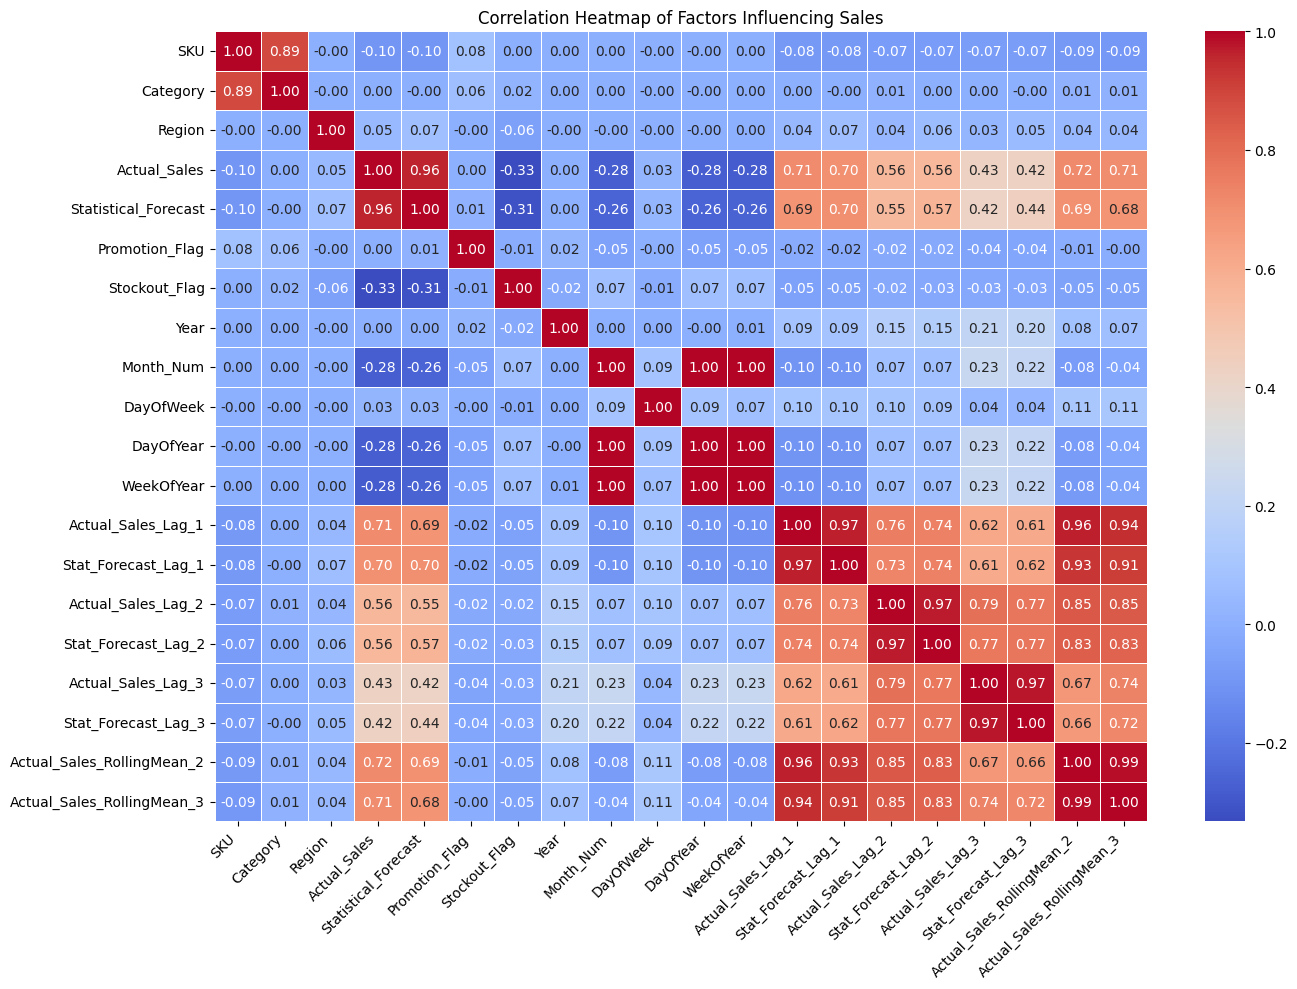

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation analysis
# Exclude original 'Month' and 'Consensus_Forecast' as they are not directly numerical features used for training target
# Also exclude any identifier columns not meant for correlation like 'SKU', 'Category', 'Region' if they are still encoded and not truly numerical measures
numerical_cols = [col for col in df_model.columns if df_model[col].dtype != 'object' and col not in [MONTH_COL, CONSENSUS_FORECAST_COL]]

# Ensure 'Actual_Sales_COL' (target) is included
if ACTUAL_SALES_COL not in numerical_cols:
    numerical_cols.append(ACTUAL_SALES_COL)

# Convert to float for correlation calculation if any int columns exist
correlation_df = df_model[numerical_cols].astype(float)

# Calculate the correlation matrix
corr_matrix = correlation_df.corr()

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Factors Influencing Sales')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

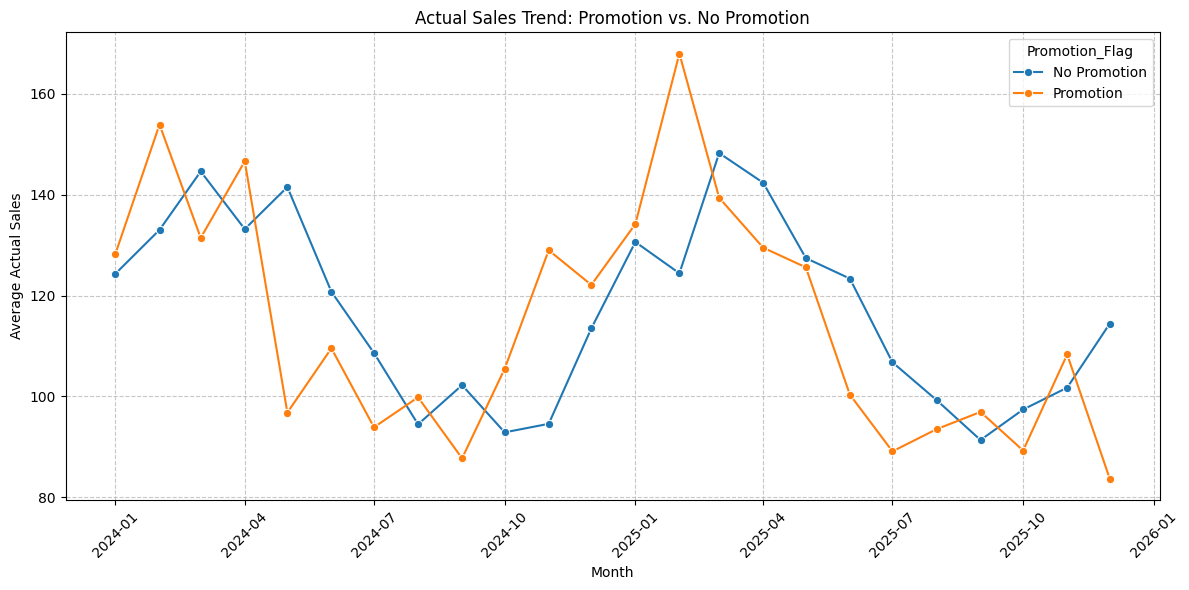

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Month column in raw_df_copy is datetime type for plotting
raw_df_copy[MONTH_COL] = pd.to_datetime(raw_df_copy[MONTH_COL])

# Group by Month and Promotion_Flag to get average sales
promotion_sales_trend = raw_df_copy.groupby([MONTH_COL, PROMOTION_FLAG_COL])[ACTUAL_SALES_COL].mean().reset_index()

# Map numerical flags to descriptive labels for better readability in the plot
promotion_sales_trend[PROMOTION_FLAG_COL] = promotion_sales_trend[PROMOTION_FLAG_COL].map({0: 'No Promotion', 1: 'Promotion'})

plt.figure(figsize=(12, 6))
sns.lineplot(data=promotion_sales_trend, x=MONTH_COL, y=ACTUAL_SALES_COL, hue=PROMOTION_FLAG_COL, marker='o')
plt.title('Actual Sales Trend: Promotion vs. No Promotion')
plt.xlabel('Month')
plt.ylabel('Average Actual Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()